In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۹: مروری بر یادگیری معیار (چه زمانی فاصله باید یاد گرفته شود)

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
macro_f1 = make_scorer(f1_score, average="macro", zero_division=0, pos_label=None)

KNN فرض می‌کند تابع فاصله‌اش از پیش شباهت معنادار را گرفته است. فاصلهٔ اقلیدسی استانداردشده نقطهٔ شروع معقولی است، اما همهٔ ویژگی‌های استانداردشده را برابر می‌بیند و ساختار کلاس را نادیده می‌گیرد. یادگیری معیار پرسش دیگری مطرح می‌کند: آیا داده و برچسب‌ها می‌توانند فاصله‌ای یاد بدهند که همسایه‌های مفید نزدیک‌تر و مثال‌های گیج‌کننده دورتر شوند؟

در این درس مفاهیم metric learning را بدون dependency خارجی تأییدنشده معرفی می‌کنیم. از دادهٔ Glass استفاده و یک معیار قطری نظارت‌شده و شفاف پیاده‌سازی می‌کنیم. این معیار برای هر ویژگی استانداردشده یک وزن نامنفی از تغییر میان‌کلاسی و درون‌کلاسی یاد می‌گیرد. نتیجه تبدیل ساده‌ای از نوع Mahalanobis است که می‌توان آن را دید، اعتبارسنجی کرد و با KNN استاندارد مقایسه کرد.

همچنین معیار Mahalanobis کامل، نظارت pair و triplet، معیار محلی و سراسری، نیازهای اعتبارسنجی و خطرهای انصاف را توضیح می‌دهیم. metric learning می‌تواند نمایش را بهتر کند، اما می‌تواند جانبداری برچسب را تقویت، دادهٔ کوچک را overfit یا فرض شباهت نادرست را پشت ماتریس یادگرفته‌شده پنهان کند.

In [3]:
class FisherDiagonalMetric(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        global_mean = X.mean(axis=0)
        between = np.zeros(X.shape[1])
        within = np.zeros(X.shape[1])
        for label in np.unique(y):
            group = X[y == label]
            between += len(group) * (group.mean(axis=0) - global_mean) ** 2
            within += ((group - group.mean(axis=0)) ** 2).sum(axis=0)
        ratio = between / (within + 1e-9)
        self.weights_ = ratio / ratio.mean()
        self.scale_ = np.sqrt(self.weights_)
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float) * self.scale_

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. توضیح دهید چرا فاصلهٔ ثابت برای KNN ممکن است ناکافی باشد.
2. فاصلهٔ Mahalanobis را بنویسید و آن را به تبدیل خطی یادگرفته‌شده ربط دهید.
3. روش‌های معیار سراسری، محلی، قطری و کامل را جدا کنید.
4. نظارت pair، triplet و همسایگی را توصیف کنید.
5. معیار قطری نظارت‌شده و تفسیرپذیر را فقط از دادهٔ آموزش پیاده‌سازی کنید.
6. معیار یادگرفته‌شده و معمولی را با اعتبارسنجی بدون نشت مقایسه کنید.
7. بررسی کنید معیار یادگرفته‌شده چگونه همسایه‌های پرس‌وجو و فاصله‌های pair را عوض می‌کند.
8. خطرهای overfitting، انصاف، کیفیت برچسب و استقرار را تشخیص دهید.

Metric learning فقط مقیاس‌بندی ویژگی نیست؛ طراحی نمایش نظارت‌شده‌ای است که هدف آن باید با کار پایین‌دستی و محدودیت‌هایش هماهنگ باشد.

In [4]:
glass_path = Path("../../../Datasets/Classification/glass.csv")
glass = pd.read_csv(glass_path)
glass_X = glass.drop(columns="Type")
glass_y = glass["Type"]

display(glass.head())
display(glass.dtypes.rename("dtype").to_frame())
display(glass_y.value_counts().rename("count").to_frame())
display(glass_X.describe().T.round(3))

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


,dtype
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,object


,count
Type,
building_windows_non_float_processed,76
building_windows_float_processed,70
headlamps,29
vehicle_windows_float_processed,17
containers,13
tableware,9


,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518,0.003,1.511,1.517,1.518,1.519,1.534
Na,214.0,13.408,0.817,10.730,12.908,13.300,13.825,17.380
Mg,214.0,2.685,1.442,0.000,2.115,3.480,3.600,4.490
Al,214.0,1.445,0.499,0.290,1.190,1.360,1.630,3.500
Si,214.0,72.651,0.775,69.810,72.280,72.790,73.088,75.410
K,214.0,0.497,0.652,0.000,0.122,0.555,0.610,6.210
Ca,214.0,8.957,1.423,5.430,8.240,8.600,9.172,16.190
Ba,214.0,0.175,0.497,0.000,0.000,0.000,0.000,3.150
Fe,214.0,0.057,0.097,0.000,0.000,0.000,0.100,0.510


## ۱. از اقلیدسی تا فاصلهٔ Mahalanobis

اقلیدسی $\lVert x-z\rVert_2$ را می‌سنجد. Mahalanobis ماتریس نیمه‌معین مثبت $M$ را وارد می‌کند:

$$
d_M(x,z)=\sqrt{(x-z)^T M (x-z)}.
$$

اگر $M=L^T L$ باشد، آنگاه $d_M(x,z)=\lVert Lx-Lz\rVert_2$ است. پس یادگیری معیار معادل یادگیری تبدیل پیش از جست‌وجوی اقلیدسی عادی است. $M$ قطری برای هر ویژگی یک وزن می‌آموزد. ماتریس کامل می‌تواند ویژگی‌ها را بچرخاند و هم‌بسته کند، اما پارامترهای بسیار بیشتری دارد و دادهٔ کوچک را overfit می‌کند.

استانداردسازی تبدیل قطری ساده بر پایهٔ مقیاس است. Metric learning متفاوت است، زیرا وزن‌ها با هدف یادگیری، اغلب برچسب یا محدودیت شباهت، انتخاب می‌شوند. تبدیل باید مانند هر مدل نظارت‌شده فقط روی دادهٔ آموزش برازش شود.

,feature,learned_weight
2,Mg,3.258
1,Na,1.686
3,Al,1.634
7,Ba,1.407
5,K,0.585
8,Fe,0.167
4,Si,0.142
6,Ca,0.067
0,RI,0.054


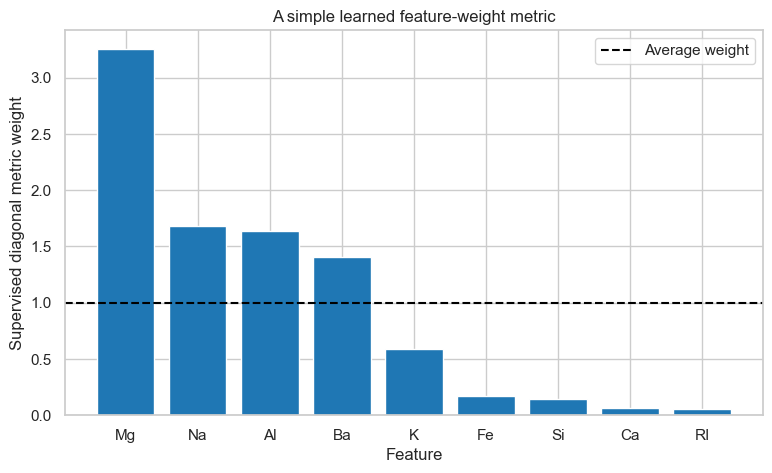

In [5]:
X_train, X_test, y_train, y_test = train_test_split(glass_X, glass_y, test_size=0.25, stratify=glass_y, random_state=RANDOM_STATE)
scaled_train = StandardScaler().fit_transform(X_train)
metric = FisherDiagonalMetric().fit(scaled_train, y_train)
feature_weights = pd.DataFrame({"feature": glass_X.columns, "learned_weight": metric.weights_}).sort_values("learned_weight", ascending=False)
display(feature_weights.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(feature_weights["feature"], feature_weights["learned_weight"], color="tab:blue")
ax.axhline(1, color="black", linestyle="--", label="Average weight")
ax.set_xlabel("Feature")
ax.set_ylabel("Supervised diagonal metric weight")
ax.set_title("A simple learned feature-weight metric")
ax.legend()
plt.show()

## ۲. سیگنال‌های نظارتی برای یادگیری معیار

روش pair محور، زوج مشابه و نامشابه می‌گیرند. فاصلهٔ زوج مشابه را کم و زوج نامشابه را زیاد می‌کنند. روش triplet از anchor، مثال مثبت و مثال منفی استفاده می‌کند و anchor را با margin به مثبت نزدیک‌تر از منفی می‌خواهد:

$$
d(a,p)+m < d(a,n).
$$

Neighborhood Component Analysis و روش‌های مرتبط تبدیلی را بهینه می‌کنند که همسایهٔ هم‌کلاس محتمل باشد. روش‌های nearest-neighbor با margin بزرگ می‌خواهند target neighbor حفظ و impostor دور شود. embeddingهای مدرن از هدف contrastive یا triplet در مقیاس بزرگ استفاده می‌کنند.

ایدهٔ مشترک این است که برچسب یا constraint تعیین می‌کند شباهت چه معنایی داشته باشد. این قدرتمند است، اما کیفیت داده را مرکزی می‌کند. برچسب شباهت نویزی یا جانبدار می‌تواند هندسهٔ زیان‌بار بیاموزد.

In [6]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
models = {
    "Standardized Euclidean KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7, weights="distance")),
    "Learned diagonal metric KNN": make_pipeline(StandardScaler(), FisherDiagonalMetric(), KNeighborsClassifier(n_neighbors=7, weights="distance")),
}
rows = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=macro_f1, error_score="raise")
    rows.append({"model": name, "mean_macro_f1": scores.mean(), "std_macro_f1": scores.std()})
comparison = pd.DataFrame(rows)
display(comparison.round(3))

,model,mean_macro_f1,std_macro_f1
0,Standardized Euclidean KNN,0.447,0.057
1,Learned diagonal metric KNN,0.539,0.029


## ۳. دادهٔ Glass و معیار قطری تفسیرپذیر

Glass اندازه‌گیری‌های شیمیایی و نوری عددی و برچسب Type چندکلاسه دارد. پیش از مدل، سطرها، نوع‌ها، تعداد کلاس‌ها و آمار خلاصه را می‌بینیم. بعضی کلاس‌ها نادرند، پس macro F1 از دقت به‌تنهایی آگاه‌کننده‌تر است. وزن قطری ساده‌ای به‌کار می‌بریم: برای هر ویژگی استانداردشده، تغییر میان‌کلاسی را با تغییر درون‌کلاسی مقایسه می‌کنیم. ویژگی با میانگین کلاس‌های متفاوت نسبت به پراکندگی درون‌کلاس وزن بیشتر می‌گیرد.

این روش الهام‌گرفته از metric learning است، نه بهینه‌ساز پیشرفته. ارزش آن شفافیت است. هر وزن را می‌بینید، تأیید می‌کنید که فقط از برچسب آموزش برازش شده و می‌آزمایید آیا اعتبارسنجی بهتر می‌شود. معیار پیچیده‌تر خودبه‌خود بهتر نیست اگر فرض یا نیاز دادهٔ آن روشن نباشد.

,model,accuracy,macro_f1
0,Standardized Euclidean KNN,0.759,0.683
1,Learned diagonal metric KNN,0.759,0.663


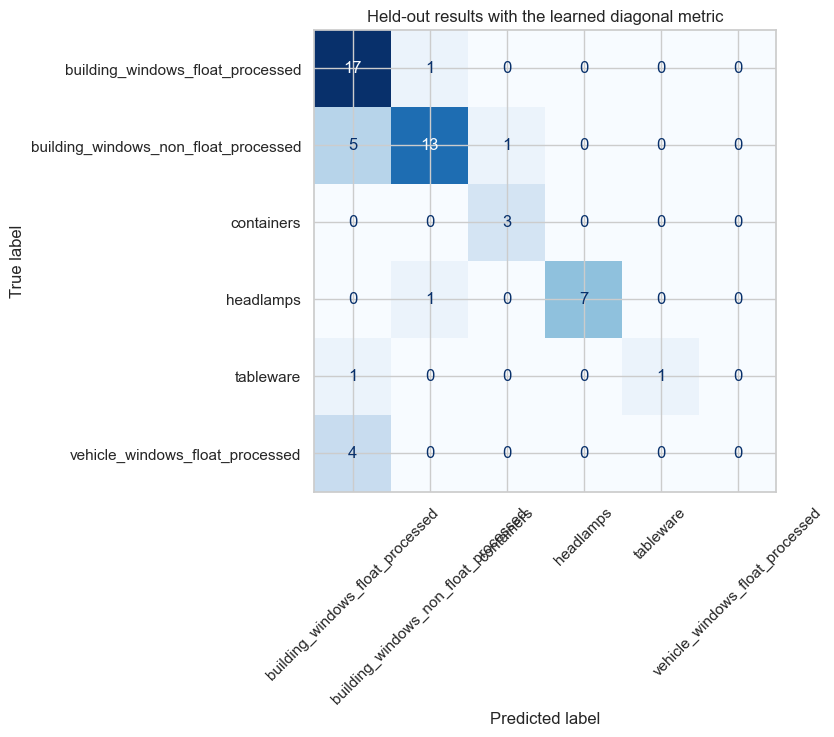

In [7]:
baseline = models["Standardized Euclidean KNN"].fit(X_train, y_train)
learned = models["Learned diagonal metric KNN"].fit(X_train, y_train)
baseline_prediction = baseline.predict(X_test)
learned_prediction = learned.predict(X_test)

test_results = pd.DataFrame({
    "model": ["Standardized Euclidean KNN", "Learned diagonal metric KNN"],
    "accuracy": [accuracy_score(y_test, baseline_prediction), accuracy_score(y_test, learned_prediction)],
    "macro_f1": [f1_score(y_test, baseline_prediction, average="macro", zero_division=0), f1_score(y_test, learned_prediction, average="macro", zero_division=0)],
})
display(test_results.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, learned_prediction, xticks_rotation=45, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Held-out results with the learned diagonal metric")
plt.show()

## ۴. هندسهٔ عادی و یادگرفته‌شده را مقایسه کنید

Transformer یادگرفته‌شده پس از StandardScaler و پیش از KNN در pipeline است. اعتبارسنجی متقابل scaler و وزن ویژگی را مستقل در هر fold آموزش برازش می‌دهد. پس برچسب اعتبارسنجی بر فاصلهٔ خودش اثر نمی‌گذارد. KNN اقلیدسی استانداردشده و معیار قطری یادگرفته‌شده را با macro F1 مقایسه می‌کنیم.

بهبود، شاهدی برای همین تقسیم و نمایش است، نه اثبات معیار همگانی. کاهش امتیاز نیز آگاه‌کننده است: وزن‌های ساده شاید خام باشند، برچسب‌ها فرض را پشتیبانی نکنند یا هندسهٔ استاندارد از پیش کافی باشد. ارزیابی صادقانه ارزشمندتر از واردکردن معیار یادگرفته‌شده به هر داده است.

In [8]:
query_index = 0
raw_scaler = StandardScaler().fit(X_train)
train_standard = raw_scaler.transform(X_train)
query_standard = raw_scaler.transform(X_test.iloc[[query_index]])
learned_transformer = FisherDiagonalMetric().fit(train_standard, y_train)
train_learned = learned_transformer.transform(train_standard)
query_learned = learned_transformer.transform(query_standard)

standard_neighbors = NearestNeighbors(n_neighbors=8).fit(train_standard)
learned_neighbors = NearestNeighbors(n_neighbors=8).fit(train_learned)
standard_distances, standard_indices = standard_neighbors.kneighbors(query_standard)
learned_distances, learned_indices = learned_neighbors.kneighbors(query_learned)

standard_table = X_train.iloc[standard_indices[0]].copy()
standard_table["class"] = y_train.iloc[standard_indices[0]].to_numpy()
standard_table["distance"] = standard_distances[0]
learned_table = X_train.iloc[learned_indices[0]].copy()
learned_table["class"] = y_train.iloc[learned_indices[0]].to_numpy()
learned_table["distance"] = learned_distances[0]

display(X_test.iloc[[query_index]].assign(actual_class=y_test.iloc[query_index]))
display(standard_table[["RI", "Na", "Mg", "Al", "Si", "class", "distance"]].sort_values("distance").round(3))
display(learned_table[["RI", "Na", "Mg", "Al", "Si", "class", "distance"]].sort_values("distance").round(3))

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,actual_class
65,1.52099,13.69,3.59,1.12,71.96,0.09,9.4,0.0,0.0,building_windows_float_processed


,RI,Na,Mg,Al,Si,class,distance
18,1.519,13.90,3.73,1.18,72.12,building_windows_float_processed,0.785
0,1.521,13.64,4.49,1.10,71.78,building_windows_float_processed,0.821
64,1.522,13.48,3.74,0.90,72.01,building_windows_float_processed,0.911
48,1.522,13.21,3.77,0.79,71.99,building_windows_float_processed,1.057
49,1.519,13.58,3.35,1.23,72.08,building_windows_float_processed,1.060
45,1.519,13.49,3.48,1.35,71.95,building_windows_float_processed,1.073
36,1.519,13.89,3.53,1.32,71.81,building_windows_float_processed,1.094
151,1.521,14.32,3.90,0.83,71.50,vehicle_windows_float_processed,1.128


,RI,Na,Mg,Al,Si,class,distance
18,1.519,13.90,3.73,1.18,72.12,building_windows_float_processed,0.440
49,1.519,13.58,3.35,1.23,72.08,building_windows_float_processed,0.714
64,1.522,13.48,3.74,0.90,72.01,building_windows_float_processed,0.733
36,1.519,13.89,3.53,1.32,71.81,building_windows_float_processed,0.812
187,1.523,13.44,3.34,1.23,72.38,headlamps,0.831
45,1.519,13.49,3.48,1.35,71.95,building_windows_float_processed,0.843
24,1.517,13.38,3.50,1.15,72.85,building_windows_float_processed,0.845
62,1.522,13.51,3.86,0.88,71.79,building_windows_float_processed,0.884


## ۵. عملکرد آزمون و همسایه‌های محلی را ببینید

مقایسهٔ آزمون کنارگذاشته‌شده پس از اعتبارسنجی یک دید نهایی می‌دهد. سپس فهرست همسایهٔ یک پرس‌وجو را پیش و پس از تبدیل بازرسی می‌کنیم. معیار یادگرفته‌شده با تأکید و کم‌تأکید بر اندازه‌گیری‌های شیمیایی می‌تواند ترتیب همسایه را عوض کند. جدول، ماتریس انتزاعی را به اثر محلی عینی تبدیل می‌کند.

تغییر همسایه خودبه‌خود خوب نیست. بپرسید همسایهٔ جدید بیشتر کلاس درست را دارند، شباهت ویژگی‌شان از نظر دامنه معقول است و کلاس نادر منصفانه دیده می‌شود یا نه. Metric learning باید همسایگی مرتبط با کار را بهتر کند، نه فقط نقطه‌ها را دیداری جابه‌جا کند.

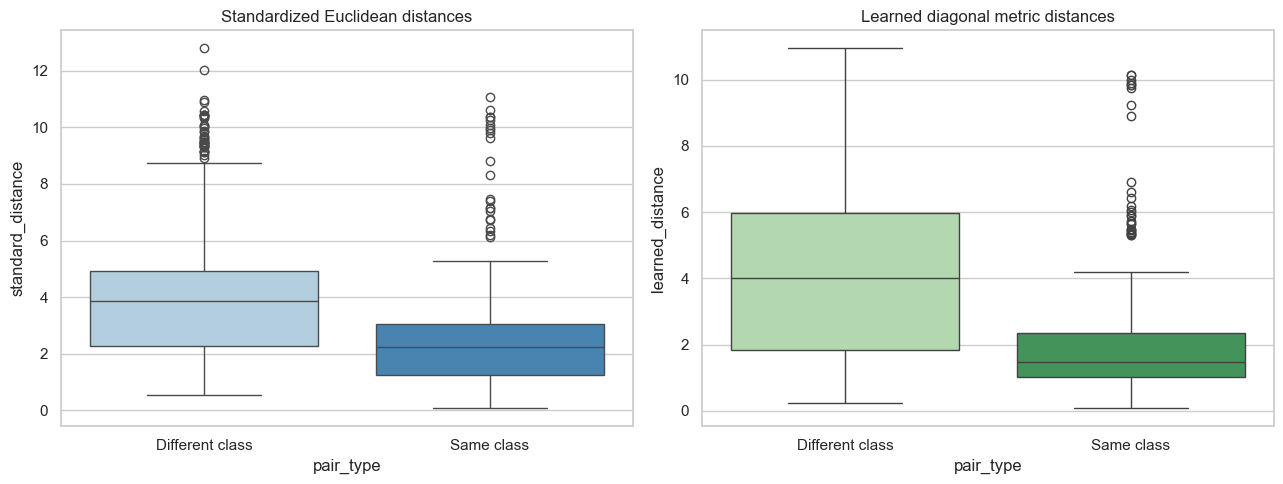

In [9]:
pair_rows = []
for _ in range(1200):
    first, second = rng.choice(len(train_standard), size=2, replace=False)
    same_class = y_train.iloc[first] == y_train.iloc[second]
    pair_rows.append({
        "pair_type": "Same class" if same_class else "Different class",
        "standard_distance": np.linalg.norm(train_standard[first] - train_standard[second]),
        "learned_distance": np.linalg.norm(train_learned[first] - train_learned[second]),
    })
pairs = pd.DataFrame(pair_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=pairs, x="pair_type", y="standard_distance", hue="pair_type", legend=False, ax=axes[0], palette="Blues")
axes[0].set_title("Standardized Euclidean distances")
sns.boxplot(data=pairs, x="pair_type", y="learned_distance", hue="pair_type", legend=False, ax=axes[1], palette="Greens")
axes[1].set_title("Learned diagonal metric distances")
plt.tight_layout()
plt.show()

## ۶. تشخیص فاصلهٔ pair

برای زوج‌های تصادفی آموزش، فاصلهٔ هم‌کلاس و متفاوت‌کلاس را زیر هندسهٔ استاندارد و معیار قطری یادگرفته‌شده مقایسه می‌کنیم. معیار نظارت‌شدهٔ مفید اغلب زوج هم‌کلاس را نسبتاً کوچک و زوج متفاوت‌کلاس را نسبتاً بزرگ می‌کند. توزیع‌ها همچنان هم‌پوشان می‌شوند؛ کلاس واقعی به‌ندرت کاملاً جداست.

این تشخیص توصیفی است، نه آزمون مستقل. معیار از همان برچسب آموزش یاد گرفته است، پس نمودار pair آموزش جذاب می‌تواند عملکرد آینده را بیش‌برآورد کند. برای تصمیم دربارهٔ پیچیدگی معیار و پارامتر KNN، آزمون کنارگذاشته‌شده یا اعتبارسنجی تودرتو نگه دارید.

## ۷. metric learning چه زمانی کمک یا آسیب می‌زند

Metric learning وقتی کمک می‌کند که ویژگی‌ها اهمیت نابرابر دارند، هم‌بستگی مهم است، شباهت معنایی با مقیاس خام گرفته نمی‌شود یا pair برچسب‌دار ساختار مفید نشان می‌دهند. برای تصویر، embedding متن، بازیابی، شباهت چهره یا محصول و مسئله با رابطهٔ مثبت و منفی روشن ارزشمند است.

وقتی برچسب نویزی است، تعریف کلاس ناپایدار است، داده برای ماتریس پیچیده کم است یا ویژگی محافظت‌شده و proxy آن وارد هندسه می‌شوند می‌تواند آسیب بزند. معیاری که دقت میانگین را بهتر می‌کند ممکن است خطای گروه اقلیت را بدتر کند. فاصلهٔ یادگرفته‌شده به versioning، monitoring، بازبینی حریم خصوصی و fallback برای پرس‌وجوی خارج از توزیع نیاز دارد.

## ۸. تمرین‌ها و جمع‌بندی

1. وزن‌های قطری را برابر یک بگذارید و تأیید کنید KNN اقلیدسی استانداردشده به‌دست می‌آید.
2. یک ویژگی Glass با وزن بالا را حذف و اعتبارسنجی را تکرار کنید.
3. معیار قطری را با PCA سپس KNN مقایسه و توضیح دهید چرا PCA metric learning نظارت‌شده نیست.
4. زوج مشابه و نامشابه مصنوعی بسازید و هدف pair-loss ساده طراحی کنید.
5. پیش از کاربرد معیار یادگرفته‌شده در توصیه یا پزشکی، بررسی‌های انصاف پیشنهاد دهید.

### جمع‌بندی

Metric learning هندسهٔ روش همسایه را یاد می‌گیرد. فاصلهٔ Mahalanobis این هندسه را با ماتریس یا تبدیل بیان می‌کند. معیار قطری نظارت‌شده و شفاف را پیاده‌سازی، با KNN اقلیدسی استانداردشده مقایسه، تغییر همسایهٔ محلی را بازرسی و توزیع فاصلهٔ pair را دیدیم. این روش وقتی شباهت یادگرفته‌شده موجه باشد ارزشمند است، اما به برازش فقط روی آموزش، اعتبارسنجی، بازبینی کیفیت برچسب و استقرار آگاه از انصاف نیاز دارد.